# **Survival Analisys: Czas oczekiwania na płatność**
## Big Enterprises vs Small and Medium Enterprises

### Analiza opóźnienia płatności ze względu na rozmiar przedsiębiorstwa
&emsp; Celem jest zbadanie wpływu rozmiaru fakturobiorcy, na czas zrealizowania płatności.
W tym celu podzielmy przedsiębiorstwa według rozmiaru na:
* *BE - Big Enterprises*
* *SME - Small and Medium Enterprises*

BE stanowią kontrahenci w 90-tym centylu pod względem ilości wystawionych faktur, natomiast na SME składa się reszta.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import lifelines as ll

data = pd.read_csv('../data/dataset_survival.csv')

#### Estymator Kaplana-Meiera
&emsp; Następnie przeprowadzimy analizę przeżycia za pomocą estymatora Kaplana-Meiera. Takie podejście pozwala na wyciągnięcie informacji również z danych cenzurowanych. W naszym przypadku są to faktury otwarte, czyli takie, które do momentu zakończenia zbierania danych nie zostały jeszcze opłacone. Algorytm bierze je pod uwagę przy estymacji funkcji przeżycia, pozostawiając je w tzw. puli ryzyka (zbiór nieopłaconych faktur) do momentu ich ocenzurowania. Umożliwia to dokładniejsze wyznaczanie prawdopobieństw. Wprowadźmy następującą notację:
* Czas przeżycia: liczba dni od wystawienia faktury do jej opłacenia.
* Zdarzenie: zamknięcie faktury.

&emsp; Algorytm dla każdego dnia wystąpienia zdarzenia, oblicza prawdopodobieństwo braku zapłaty w tym dniu pod warunkiem "przetrwania" faktur do tego momentu.

In [19]:
kmf_be = ll.KaplanMeierFitter()
kmf_sme = ll.KaplanMeierFitter()

be_data = data[data['segment'] == 'BE']
sme_data = data[data['segment'] == 'SME']

kmf_be.fit(be_data['time_days'], event_observed=be_data['event'], label='BE')
kmf_sme.fit(sme_data['time_days'], event_observed=sme_data['event'], label='SME')

<lifelines.KaplanMeierFitter:"SME", fitted with 7801 total observations, 1320 right-censored observations>

#### Wizualizacja
&emsp; Wygenerujmy krzywe przeżycia dla obu badanych kategorii przedsiębiorstw. Oś X wyznacza czas przeżycia - liczbę dni, które upłynęły od wystawienia faktury. Z kolei oś Y opisuje prawdopodobieństwo, że faktura nadal jest nieopłacona.

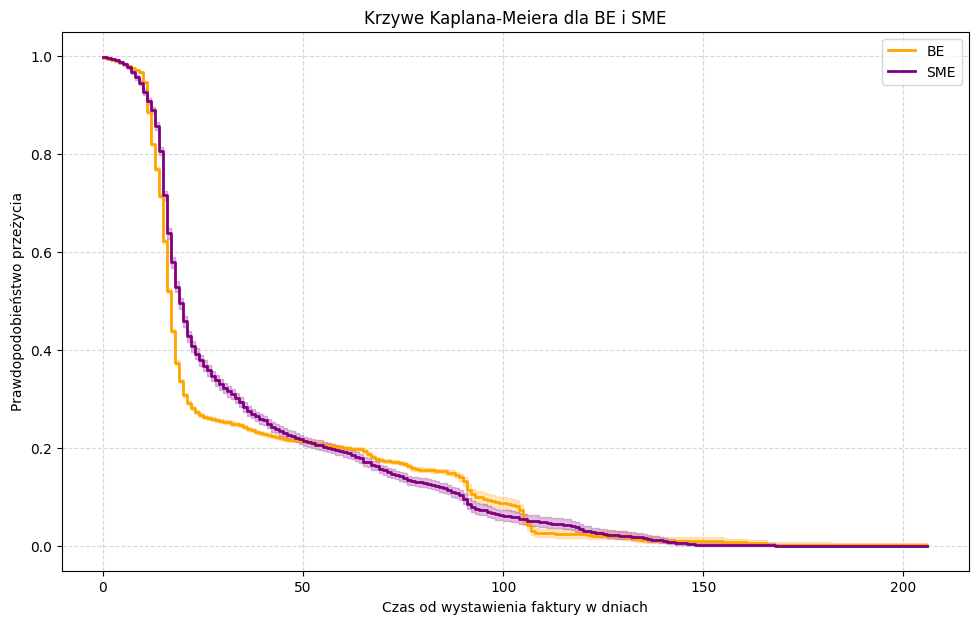

In [20]:
plt.figure(figsize=(11.7,7))

kmf_be.plot_survival_function(ci_show=True, color='orange', linewidth=2)
kmf_sme.plot_survival_function(ci_show=True, color='purple', linewidth=2)

plt.title('Krzywe Kaplana-Meiera dla BE i SME')
plt.xlabel('Czas od wystawienia faktury w dniach')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Walidacja
&emsp; Aby upewnić się, że krzywe przeżycia faktur wystawianych obu grupom są istotne różne skorzystamy z testu Log-Rank. Wartość p-value odpowie na pytanie czy różnice w danych są istotne statystycznie i mogą świadczyć o rzeczywistych rozbieżnościach w zachowaniach płatniczych.

In [21]:
results = ll.statistics.logrank_test(be_data['time_days'], sme_data['time_days'], event_observed_A=be_data['event'], event_observed_B=sme_data['event'])

print(f"p-value: {results.p_value}\n")

if results.p_value < 0.05:
    print("Różnica jest istotna statystycznie.")
else:
    print("Różnica nie jest istotna statystycznie.")

p-value: 2.966761118172522e-29

Różnica jest istotna statystycznie.


### Wnioski
&emsp; Na podstawie przeprowadzonej analizy możemy wyciągnąć wniosek, że zachowania płatnicze kontrahentów różnią się w zależności od ich rozmiaru. Oznacza to, że przynależność do którejś z grup jest istotnym predyktorem i powinna stanowić cechę dla modelu.